# Stage 07 Homework Submission - Outliers and Risk Assumptions

This submission starts from the official starter, packages improved functions, and evaluates how raw, filtered, and winsorized treatments change both descriptive statistics and a simple regression.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

ROOT = Path.cwd()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.grid': True, 'grid.alpha': 0.25})

## 1. Generate the official starter dataset

In [2]:
dates = pd.date_range(start='2022-01-03', end='2022-06-10', freq='B')
rng = np.random.default_rng(17)
returns = rng.normal(0, 0.01, size=len(dates))
returns[dates < '2022-05-01'] -= 0.0015
shocks = {
    '2022-05-02': 0.1748425237194541,
    '2022-05-03': -0.16825801732486943,
    '2022-05-06': -0.19667220757153227,
    '2022-05-09': 0.21240223590614747,
    '2022-05-12': -0.178729287231294,
}
for day, value in shocks.items():
    returns[np.where(dates == pd.Timestamp(day))[0][0]] = value
daily_return_2 = returns * 0.6 + rng.normal(0, 0.005, size=len(dates))
df = pd.DataFrame({'date': dates, 'daily_return': returns, 'daily_return_2': daily_return_2})
raw_path = RAW / 'outliers_homework.csv'
df.to_csv(raw_path, index=False)
display(df.head())
print('Rows:', len(df), '| Missing values:', int(df.isna().sum().sum()))

,date,daily_return,daily_return_2
0,2022-01-03,0.009513,0.007771
1,2022-01-04,0.001884,-0.000414
2,2022-01-05,-0.006900,-0.017307
3,2022-01-06,-0.014102,-0.007351
4,2022-01-07,-0.020446,-0.013652


Rows: 115 | Missing values: 0


## 2. Detect and flag outliers

IQR uses `k=1.5` because it is distribution-robust and aligns with the boxplot convention. The z-score comparison uses the stated `3.0` population-standard-deviation threshold; it is less reliable under heavy tails because the extreme values inflate its own mean and standard deviation.

In [3]:
target_col = 'daily_return'
df['outlier_iqr'] = detect_outliers_iqr(df[target_col], k=1.5)
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
flag_summary = pd.DataFrame({
    'count': df[['outlier_iqr', 'outlier_z']].sum(),
    'fraction': df[['outlier_iqr', 'outlier_z']].mean(),
})
display(flag_summary)
display(df.loc[df['outlier_iqr'] | df['outlier_z'], ['date', target_col, 'outlier_iqr', 'outlier_z']])

,count,fraction
outlier_iqr,5,0.043478
outlier_z,5,0.043478


,date,daily_return,outlier_iqr,outlier_z
85,2022-05-02,0.174843,True,True
86,2022-05-03,-0.168258,True,True
89,2022-05-06,-0.196672,True,True
90,2022-05-09,0.212402,True,True
93,2022-05-12,-0.178729,True,True


## 3. Sensitivity of summary statistics

In [4]:
winsorized_return = winsorize_series(df[target_col], lower=0.05, upper=0.95)
summary_table = pd.DataFrame({
    'all': df[target_col].agg(['mean', 'median', 'std']),
    'filtered_iqr': df.loc[~df['outlier_iqr'], target_col].agg(['mean', 'median', 'std']),
    'winsorized_05_95': winsorized_return.agg(['mean', 'median', 'std']),
}).T
display(summary_table)
summary_table.to_csv(PROCESSED / 'summary_sensitivity.csv')

,mean,median,std
all,-0.003138,-0.002156,0.040475
filtered_iqr,-0.001859,-0.002087,0.010875
winsorized_05_95,-0.002223,-0.002156,0.011072


## 4. Sensitivity of a simple regression

In [5]:
variants = {
    'all': (df['daily_return'], df['daily_return_2']),
    'filtered_iqr': (
        df.loc[~df['outlier_iqr'], 'daily_return'],
        df.loc[~df['outlier_iqr'], 'daily_return_2'],
    ),
    'winsorized_05_95': (
        winsorize_series(df['daily_return'], 0.05, 0.95),
        winsorize_series(df['daily_return_2'], 0.05, 0.95),
    ),
}

rows = []
fitted_variants = {}
for name, (x_values, y_values) in variants.items():
    X = x_values.to_numpy().reshape(-1, 1)
    y = y_values.to_numpy()
    model = LinearRegression().fit(X, y)
    prediction = model.predict(X)
    fitted_variants[name] = (x_values, y_values, model)
    rows.append({
        'variant': name,
        'n': len(y),
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': r2_score(y, prediction),
        'mae': mean_absolute_error(y, prediction),
    })
regression_results = pd.DataFrame(rows).set_index('variant')
display(regression_results)
regression_results.to_csv(PROCESSED / 'regression_sensitivity.csv')

,n,slope,intercept,r2,mae
variant,,,,,
all,115,0.581999,-0.000467,0.958325,0.003734
filtered_iqr,110,0.565447,-0.000398,0.603646,0.003771
winsorized_05_95,115,0.597067,-0.000296,0.656127,0.003643


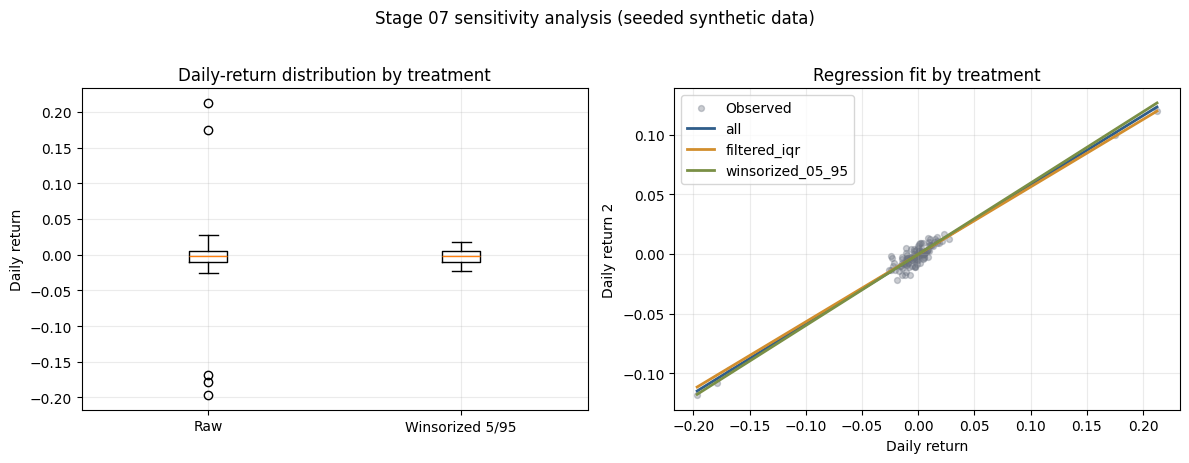

Saved: /Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework07/data/processed/outlier_sensitivity.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(
    [df['daily_return'], winsorized_return],
    tick_labels=['Raw', 'Winsorized 5/95'],
)
axes[0].set_title('Daily-return distribution by treatment')
axes[0].set_ylabel('Daily return')

colors = {'all': '#2F5D8A', 'filtered_iqr': '#D28E2D', 'winsorized_05_95': '#7A8F45'}
x_grid = np.linspace(df['daily_return'].min(), df['daily_return'].max(), 200).reshape(-1, 1)
axes[1].scatter(df['daily_return'], df['daily_return_2'], s=18, alpha=0.35, color='#6B7280', label='Observed')
for name, (_, _, model) in fitted_variants.items():
    axes[1].plot(x_grid, model.predict(x_grid), label=name, color=colors[name], linewidth=2)
axes[1].set_title('Regression fit by treatment')
axes[1].set_xlabel('Daily return')
axes[1].set_ylabel('Daily return 2')
axes[1].legend()
fig.suptitle('Stage 07 sensitivity analysis (seeded synthetic data)', y=1.02)
fig.tight_layout()
figure_path = PROCESSED / 'outlier_sensitivity.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', figure_path)

## 5. Reflection

The IQR rule and 3-sigma rule are both reported because they answer different questions. IQR is less distorted by heavy tails; z-scores are easy to communicate but implicitly treat the distribution as roughly bell-shaped. The executed flag table shows whether the two methods agree on the five deliberately injected shocks.

The sensitivity tables show that removing or capping shocks sharply reduces the standard deviation, while the median changes much less than the mean. The regression slope should remain near the data-generating relationship of 0.6, but fit metrics move because the most influential observations are also the points that make the linear relationship visually strongest. Therefore, a higher in-sample R² after one treatment is not automatic evidence that the treatment is better.

The main risk is deleting genuine market events. An IQR flag is an investigation label, not proof of bad data. Filtering changes the population; winsorization changes observed values. For risk estimation, the raw tail events should be retained or modeled separately unless independent evidence shows a data error. The correct production next step is to keep the flags, document the event dates, compare out-of-sample performance, and report both typical-period and stress-period risk.